# Visualization

Build the final visualization/dashboard.

# SpaceCast — Notebook 06: Forecasting Results & Visualization

**Project:** SpaceCast — Geomagnetic Space Weather Forecasting  
**Target:** Dst index (nT) · **Test period:** 2024–2025 · **Horizons:** 1 h, 3 h, 6 h, 12 h, 24 h

---

This notebook is the **final visual story** for SpaceCast.

| Notebook | Role |
|---|---|
| 04 | Generated all forecasts (Chronos-2, TimesFM-3 univariate, TimesFM-3 multivariate) and statistical baselines |
| 05 | Performed rigorous numerical evaluation — MAE, RMSE, correlation, storm conditioning |
| **06 (this notebook)** | **Transforms those results into publication-ready figures** |

No models are retrained or re-run here.  
All figures are derived from the aggregate metric files saved by Notebook 04 and inspected in Notebook 05, plus the cleaned OMNI2 source data for the May 2024 event.


## Visualization Goals

Each figure in this notebook answers a concrete scientific or operational question:

| Figure | Question |
|---|---|
| 1 — MAE vs Horizon | Which model is most accurate, and how fast does error grow? |
| 2 — RMSE vs Horizon | How are large storm-time errors distributed across models? |
| 3 — Correlation vs Horizon | How well do forecasts co-vary with observations? |
| 4 — Improvement over Persistence | Which models add value beyond the naïve baseline? |
| 5 — Univariate vs Multivariate MAE | Do solar-wind covariates improve TimesFM-3? |
| 6 — Covariate MAE Improvement % | How large is the covariate benefit at each horizon? |
| 7 — Storm-Conditioned MAE | How do models perform during geomagnetic storms? |
| 8 — Global vs Storm MAE | How much harder are extreme events than typical conditions? |
| 9 — May 2024 Solar-Wind Drivers | What drove the G5 storm physically? |
| 10 — May 2024 Model Performance | How did models compare during the most extreme 2024–2025 event? |
| 11 — Final Scorecard | One-page summary of all models across all metrics |


In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

warnings.filterwarnings("ignore", category=FutureWarning)

# ── Consistent figure style ────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "axes.edgecolor":     "#333333",
    "axes.linewidth":     0.9,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#e0e0e0",
    "grid.linewidth":     0.6,
    "grid.alpha":         1.0,
    "axes.labelsize":     11,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "xtick.labelsize":    10,
    "ytick.labelsize":    10,
    "legend.fontsize":    9,
    "legend.framealpha":  0.9,
    "legend.edgecolor":   "#cccccc",
    "lines.linewidth":    2.0,
    "lines.markersize":   7,
    "font.family":        "sans-serif",
    "figure.dpi":         120,
    "savefig.dpi":        150,
    "savefig.bbox":       "tight",
})

# ── Paths ──────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, ".."))
RESULTS_DIR  = os.path.join(PROJECT_ROOT, "reports", "results")
FIGURES_DIR  = os.path.join(PROJECT_ROOT, "reports", "figures")
DATA_DIR     = os.path.join(PROJECT_ROOT, "data", "raw")

os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"Results  : {RESULTS_DIR}")
print(f"Figures  : {FIGURES_DIR}")
print(f"Data     : {DATA_DIR}")


Results  : c:\TSFM_project\SpaceCast\reports\results
Figures  : c:\TSFM_project\SpaceCast\reports\figures
Data     : c:\TSFM_project\SpaceCast\data\raw


## Load Evaluation Results

All figures in Notebook 06 are built from the three metric CSV files produced by Notebook 04 and verified in Notebook 05.

| File | Contents |
|---|---|
| `tsfm_metrics_full.csv` | MAE, RMSE, Pearson correlation for all 5 models × 5 horizons |
| `tsfm_metrics_univariate.csv` | Same metrics for the 4 univariate models only |
| `tsfm_metrics_dst_lt_50.csv` | Storm-conditioned metrics — Dst < −50 nT and Dst < −100 nT, 4 univariate models |

The May 2024 event visualization uses the cleaned OMNI2 source file (`omni2_2016_2025_clean.csv`).

> Raw per-origin forecast arrays and quantile arrays were **not serialised** by Notebook 04. Figures that would require them are replaced with the strongest valid alternative using the available aggregate metrics.


In [6]:
# ── File paths ─────────────────────────────────────────────────────────────────
_FULL_PATH  = os.path.join(RESULTS_DIR, "tsfm_metrics_full.csv")
_UNIV_PATH  = os.path.join(RESULTS_DIR, "tsfm_metrics_univariate.csv")
_STORM_PATH = os.path.join(RESULTS_DIR, "tsfm_metrics_dst_lt_50.csv")

for label, path in [
    ("tsfm_metrics_full.csv",       _FULL_PATH),
    ("tsfm_metrics_univariate.csv", _UNIV_PATH),
    ("tsfm_metrics_dst_lt_50.csv",  _STORM_PATH),
]:
    if not os.path.isfile(path):
        raise FileNotFoundError(
            f"Missing: {path}\n"
            f"Run Notebook 04 first to generate '{label}'."
        )

# ── Load ───────────────────────────────────────────────────────────────────────
df_full  = pd.read_csv(_FULL_PATH)
df_univ  = pd.read_csv(_UNIV_PATH)
df_storm = pd.read_csv(_STORM_PATH)

# ── Column validation ──────────────────────────────────────────────────────────
_req_full  = {"Horizon", "Model", "MAE", "RMSE", "Correlation"}
_req_storm = {"Horizon", "Model", "Count_lt_50", "MAE_lt_50", "RMSE_lt_50",
              "Count_lt_100", "MAE_lt_100", "RMSE_lt_100"}

for label, df, req in [("full", df_full, _req_full), ("storm", df_storm, _req_storm)]:
    missing = req - set(df.columns)
    if missing:
        raise ValueError(f"tsfm_metrics_{label}.csv is missing columns: {missing}")

# ── Confirmation ───────────────────────────────────────────────────────────────
print("tsfm_metrics_full.csv")
print(f"  Shape    : {df_full.shape}")
print(f"  Horizons : {sorted(df_full['Horizon'].unique())}")
print(f"  Models   : {sorted(df_full['Model'].unique())}")
print()
print("tsfm_metrics_univariate.csv")
print(f"  Shape    : {df_univ.shape}")
print(f"  Models   : {sorted(df_univ['Model'].unique())}")
print()
print("tsfm_metrics_dst_lt_50.csv")
print(f"  Shape    : {df_storm.shape}")
print(f"  Models   : {sorted(df_storm['Model'].unique())}")
print(f"  Storm cols: {[c for c in df_storm.columns if 'lt' in c]}")


tsfm_metrics_full.csv
  Shape    : (25, 5)
  Horizons : [np.int64(1), np.int64(3), np.int64(6), np.int64(12), np.int64(24)]
  Models   : ['ar24', 'chronos2', 'persistence', 'timesfm3', 'timesfm3_mv']

tsfm_metrics_univariate.csv
  Shape    : (20, 5)
  Models   : ['ar24', 'chronos2', 'persistence', 'timesfm3']

tsfm_metrics_dst_lt_50.csv
  Shape    : (20, 8)
  Models   : ['ar24', 'chronos2', 'persistence', 'timesfm3']
  Storm cols: ['Count_lt_50', 'MAE_lt_50', 'RMSE_lt_50', 'Count_lt_100', 'MAE_lt_100', 'RMSE_lt_100']


## Consistent Model Labels

To keep all figures readable and consistent, internal CSV model labels are mapped to display names before any plotting.

| CSV label | Display name | Description |
|---|---|---|
| `persistence` | Persistence | Last observed Dst held constant for all lead times |
| `ar24` | AR(24) | Linear autoregression on the last 24 hours of Dst |
| `chronos2` | Chronos-2 | Amazon Chronos-2, zero-shot pretrained TSFM |
| `timesfm3` | TimesFM-3 | Google TimesFM-3, zero-shot, univariate Dst only |
| `timesfm3_mv` | TimesFM-3 MV | TimesFM-3 with past solar-wind covariates |

The same names, colors, and ordering are used across every figure.


In [7]:
# ── Display labels ─────────────────────────────────────────────────────────────
LABEL_MAP = {
    "persistence":  "Persistence",
    "ar24":         "AR(24)",
    "chronos2":     "Chronos-2",
    "timesfm3":     "TimesFM-3",
    "timesfm3_mv":  "TimesFM-3 MV",
}

# Fixed model display order (used in every plot)
MODEL_ORDER = ["persistence", "ar24", "chronos2", "timesfm3", "timesfm3_mv"]
MODEL_ORDER_DISPLAY = [LABEL_MAP[m] for m in MODEL_ORDER]

# ── Fixed model colors (ColorBrewer-inspired, distinguishable, colorblind-safe) ─
MODEL_COLORS = {
    "Persistence":     "#888888",   # neutral grey
    "AR(24)":          "#2166ac",   # medium blue
    "Chronos-2":       "#d6604d",   # muted red-orange
    "TimesFM-3":       "#1a9641",   # green
    "TimesFM-3 MV":    "#7b2d8b",   # purple
}

# ── Fixed line styles ──────────────────────────────────────────────────────────
MODEL_LINESTYLE = {
    "Persistence":     (0, (3, 1)),   # dense dash
    "AR(24)":          "--",
    "Chronos-2":       "-.",
    "TimesFM-3":       "-",
    "TimesFM-3 MV":    "-",
}

# ── Fixed markers ──────────────────────────────────────────────────────────────
MODEL_MARKER = {
    "Persistence":    "s",
    "AR(24)":         "D",
    "Chronos-2":      "^",
    "TimesFM-3":      "o",
    "TimesFM-3 MV":   "P",
}

# ── Apply display labels to dataframes ────────────────────────────────────────
df_full["Model_label"]  = df_full["Model"].map(LABEL_MAP).fillna(df_full["Model"])
df_univ["Model_label"]  = df_univ["Model"].map(LABEL_MAP).fillna(df_univ["Model"])
df_storm["Model_label"] = df_storm["Model"].map(LABEL_MAP).fillna(df_storm["Model"])

HORIZONS = sorted(df_full["Horizon"].unique())   # [1, 3, 6, 12, 24]

print("Model order  :", MODEL_ORDER_DISPLAY)
print("Horizons     :", HORIZONS)
print("Color palette:", MODEL_COLORS)


Model order  : ['Persistence', 'AR(24)', 'Chronos-2', 'TimesFM-3', 'TimesFM-3 MV']
Horizons     : [np.int64(1), np.int64(3), np.int64(6), np.int64(12), np.int64(24)]
Color palette: {'Persistence': '#888888', 'AR(24)': '#2166ac', 'Chronos-2': '#d6604d', 'TimesFM-3': '#1a9641', 'TimesFM-3 MV': '#7b2d8b'}


## Figure 1 — MAE vs Forecast Horizon

**Mean Absolute Error (MAE)** measures the average absolute difference between model forecasts and observed Dst, in nT. Lower is better.

This figure gives the primary accuracy comparison:

- How difficult is short-horizon vs. long-horizon forecasting?
- Which model achieves the lowest error at each lead time?
- How large is the gap between TSFMs and the statistical baselines?

The test population covers the full 2024–2025 held-out period (~1,614 rolling forecast origins).  
Forecast windows overlap substantially, so these are descriptive performance summaries, not independent statistical tests.


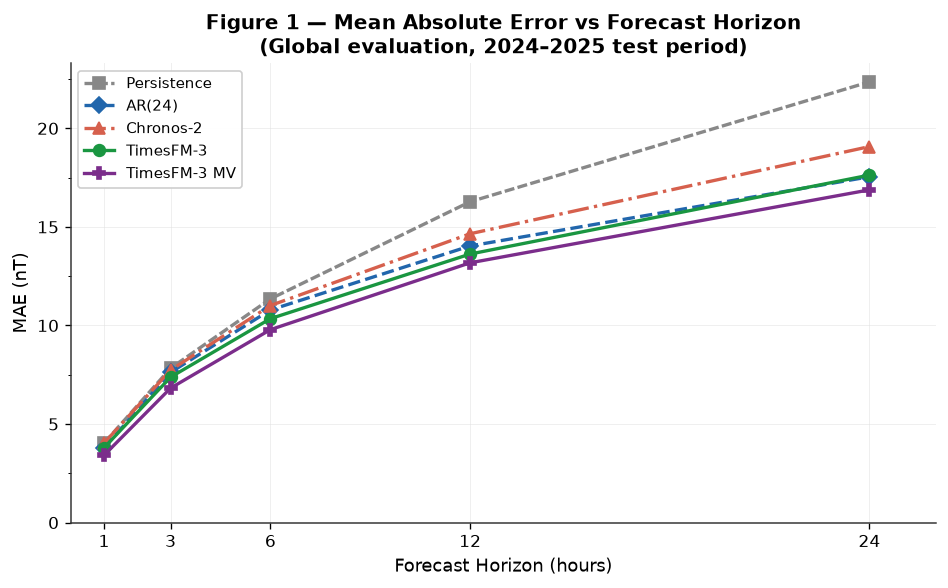

Saved → fig01_mae_vs_horizon.png


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

for m_key in MODEL_ORDER:
    m_label = LABEL_MAP[m_key]
    sub = df_full[df_full["Model"] == m_key].sort_values("Horizon")
    if sub.empty:
        continue
    ax.plot(
        sub["Horizon"], sub["MAE"],
        color=MODEL_COLORS[m_label],
        linestyle=MODEL_LINESTYLE[m_label],
        marker=MODEL_MARKER[m_label],
        label=m_label,
        zorder=3 if "MV" in m_label else 2,
    )

ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("MAE (nT)")
ax.set_title("Figure 1 — Mean Absolute Error vs Forecast Horizon\n(Global evaluation, 2024–2025 test period)")
ax.set_xticks(HORIZONS)
ax.set_xlim(0, 26)
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", framealpha=0.95)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(True, which="major", alpha=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig01_mae_vs_horizon.png"))
plt.show()
print("Saved → fig01_mae_vs_horizon.png")


## Figure 1 — Interpretation

**Key observations from the actual evaluation results:**

- **Error grows monotonically with horizon** for all models. The jump from 6 h to 12 h to 24 h is the steepest, reflecting that Dst can change substantially over multi-hour intervals.
- **TimesFM-3 MV (purple) achieves the lowest MAE at every horizon**, ranging from 3.4 nT at 1 h to 16.9 nT at 24 h. The improvement over the univariate TimesFM-3 is consistent across all lead times.
- **AR(24) and TimesFM-3 (univariate) are closely matched**, especially at 24 h (~17.5 vs. 17.6 nT). TimesFM-3 edges ahead at 3 h–12 h, while AR(24) has a marginal advantage at 24 h, suggesting the linear 24-hour autoregressive structure captures some of the same pattern a TSFM learns.
- **Chronos-2 performs above persistence at all horizons beyond 1 h** but does not match TimesFM-3 or AR(24) in this evaluation. Its MAE is closest to persistence at short horizons.
- **Persistence is the hardest baseline to beat at 1 h** (MAE 4.03 nT vs. all other models near 3.4–4.0 nT), consistent with the high short-lag autocorrelation of Dst (~0.98 at 1 h).

> These differences reflect evaluation performance on this specific test period. They do not constitute a formal statistical test.


## Figure 2 — RMSE vs Forecast Horizon

**Root Mean Squared Error (RMSE)** penalises large errors quadratically. A single missed storm excursion of 100 nT contributes 10,000 to the squared error sum — the same as 100 ordinary misses of 10 nT each.

For space weather forecasting, RMSE is arguably more mission-relevant than MAE because **missed storm peaks have the highest operational consequences**.

Comparing RMSE alongside MAE reveals whether models produce a heavy tail of large errors (high RMSE/MAE ratio) or whether their errors are more uniformly distributed.


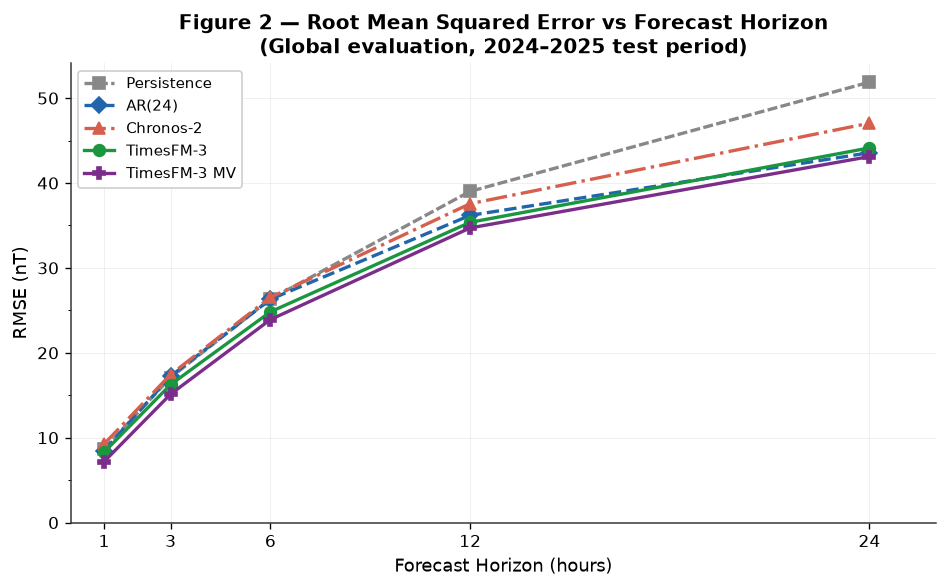

Saved → fig02_rmse_vs_horizon.png


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

for m_key in MODEL_ORDER:
    m_label = LABEL_MAP[m_key]
    sub = df_full[df_full["Model"] == m_key].sort_values("Horizon")
    if sub.empty:
        continue
    ax.plot(
        sub["Horizon"], sub["RMSE"],
        color=MODEL_COLORS[m_label],
        linestyle=MODEL_LINESTYLE[m_label],
        marker=MODEL_MARKER[m_label],
        label=m_label,
        zorder=3 if "MV" in m_label else 2,
    )

ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("RMSE (nT)")
ax.set_title("Figure 2 — Root Mean Squared Error vs Forecast Horizon\n(Global evaluation, 2024–2025 test period)")
ax.set_xticks(HORIZONS)
ax.set_xlim(0, 26)
ax.set_ylim(bottom=0)
ax.legend(loc="upper left", framealpha=0.95)
ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
ax.grid(True, which="major", alpha=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig02_rmse_vs_horizon.png"))
plt.show()
print("Saved → fig02_rmse_vs_horizon.png")


## Figure 3 — Forecast Correlation vs Horizon

**Pearson correlation** ($r$) measures how well the forecasted values co-vary with the observed Dst. A value of $r = 1$ means perfect linear agreement; $r = 0$ means no linear relationship.

Higher correlation is better.

**Important limitation:** Correlation is not an error metric. A model that produces a constant offset from the truth can have high correlation but poor MAE. Conversely, a model with moderate MAE can have lower correlation if it systematically leads or lags the observed signal by a few hours. We report it as a complementary diagnostic, not a substitute for MAE or RMSE.

The rapid fall of correlation from ~0.98 at 1 h to ~0.35 at 24 h quantifies how quickly the geomagnetic state becomes unpredictable from past observations alone.


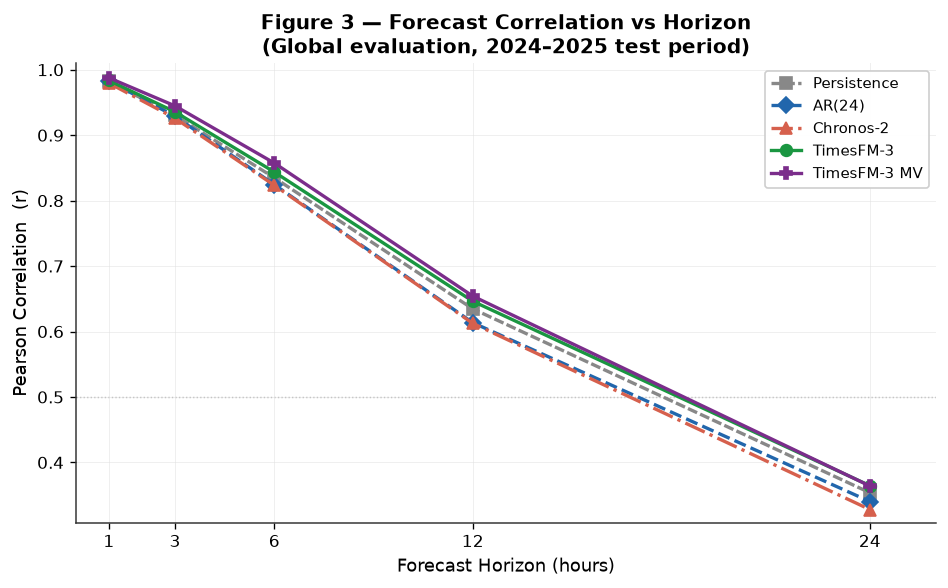

Saved → fig03_correlation_vs_horizon.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

for m_key in MODEL_ORDER:
    m_label = LABEL_MAP[m_key]
    sub = df_full[df_full["Model"] == m_key].sort_values("Horizon")
    if sub.empty:
        continue
    ax.plot(
        sub["Horizon"], sub["Correlation"],
        color=MODEL_COLORS[m_label],
        linestyle=MODEL_LINESTYLE[m_label],
        marker=MODEL_MARKER[m_label],
        label=m_label,
        zorder=3 if "MV" in m_label else 2,
    )

# y-axis: set based on actual data range with a little breathing room
_all_corr = df_full["Correlation"]
ax.set_ylim(_all_corr.min() - 0.02, 1.01)
ax.axhline(0.5, color="#aaaaaa", linewidth=0.8, linestyle=":", zorder=1)

ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("Pearson Correlation  (r)")
ax.set_title("Figure 3 — Forecast Correlation vs Horizon\n(Global evaluation, 2024–2025 test period)")
ax.set_xticks(HORIZONS)
ax.set_xlim(0, 26)
ax.legend(loc="upper right", framealpha=0.95)
ax.grid(True, which="major", alpha=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig03_correlation_vs_horizon.png"))
plt.show()
print("Saved → fig03_correlation_vs_horizon.png")


## Figure 4 — Improvement Over Persistence

The baseline question for any forecasting model is:

> **Does it beat persistence?**

Persistence requires zero training, zero parameters, and zero computation — it is the strongest short-horizon reference for Dst. Any model failing to beat it at a given horizon provides no marginal operational value.

The improvement is computed horizon-specifically:

$$\text{Improvement (\%)} = 100 \times \frac{\text{MAE}_{\text{persistence}} - \text{MAE}_{\text{model}}}{\text{MAE}_{\text{persistence}}}$$

- **Positive** = model beats persistence
- **Negative** = model is worse than persistence
- **Zero line** = parity with persistence



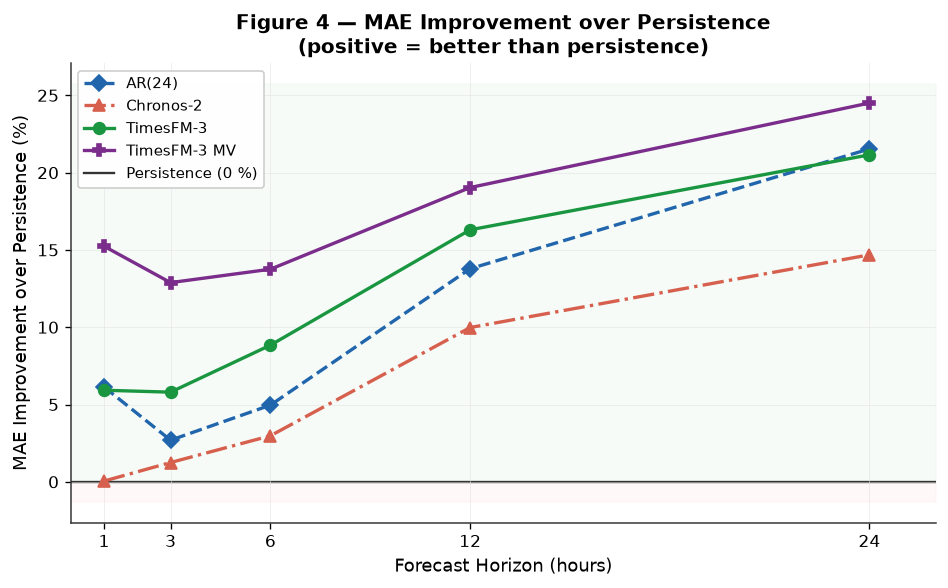

Saved → fig04_improvement_over_persistence.png


In [11]:
# ── Compute % MAE improvement over persistence ─────────────────────────────────
pers_mae = (
    df_full[df_full["Model"] == "persistence"]
    .set_index("Horizon")["MAE"]
)

impr_rows = []
for m_key in MODEL_ORDER:
    if m_key == "persistence":
        continue
    sub = df_full[df_full["Model"] == m_key].sort_values("Horizon")
    for _, row in sub.iterrows():
        h = row["Horizon"]
        p = pers_mae.get(h, np.nan)
        if np.isnan(p) or p == 0:
            impr_pct = np.nan
        else:
            impr_pct = 100.0 * (p - row["MAE"]) / p
        impr_rows.append({
            "Horizon":     h,
            "Model":       m_key,
            "Model_label": LABEL_MAP[m_key],
            "impr_pct":    impr_pct,
        })
df_impr = pd.DataFrame(impr_rows)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for m_key in [m for m in MODEL_ORDER if m != "persistence"]:
    m_label = LABEL_MAP[m_key]
    sub = df_impr[df_impr["Model"] == m_key].sort_values("Horizon")
    ax.plot(
        sub["Horizon"], sub["impr_pct"],
        color=MODEL_COLORS[m_label],
        linestyle=MODEL_LINESTYLE[m_label],
        marker=MODEL_MARKER[m_label],
        label=m_label,
        zorder=3 if "MV" in m_label else 2,
    )

# Zero-line (= persistence) — make it visually prominent
ax.axhline(0, color="#333333", linewidth=1.4, linestyle="-", zorder=1,
           label="Persistence (0 %)")
ax.fill_between([0, 26], 0, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 30,
                color="#e8f5e9", alpha=0.35, zorder=0)
ax.fill_between([0, 26], ax.get_ylim()[0] if ax.get_ylim()[0] < 0 else -5, 0,
                color="#ffebee", alpha=0.35, zorder=0)

ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("MAE Improvement over Persistence (%)")
ax.set_title("Figure 4 — MAE Improvement over Persistence\n(positive = better than persistence)")
ax.set_xticks(HORIZONS)
ax.set_xlim(0, 26)
ax.legend(loc="upper left", framealpha=0.95)
ax.grid(True, which="major", alpha=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig04_improvement_over_persistence.png"))
plt.show()
print("Saved → fig04_improvement_over_persistence.png")


## Figure 5 — Benefit of Physical Covariates: TimesFM-3 vs TimesFM-3 MV

**Central SpaceCast application question:**

Does providing the model with physically motivated upstream solar-wind observations improve Dst forecasting?

| Configuration | Input covariates |
|---|---|
| **TimesFM-3 (univariate)** | Dst history only (2,048-hour context) |
| **TimesFM-3 MV (multivariate)** | Dst + Bz GSM + solar-wind speed + density + dynamic pressure + electric field |

The multivariate configuration uses the TimesFM-3 `past_only_covariates` API, so future covariate values are **never** fabricated — the model sees only what was observable up to the forecast origin.

Figure 5 presents the direct MAE comparison across all five horizons.  
Figure 6 (next section) shows the same result as a percentage improvement.


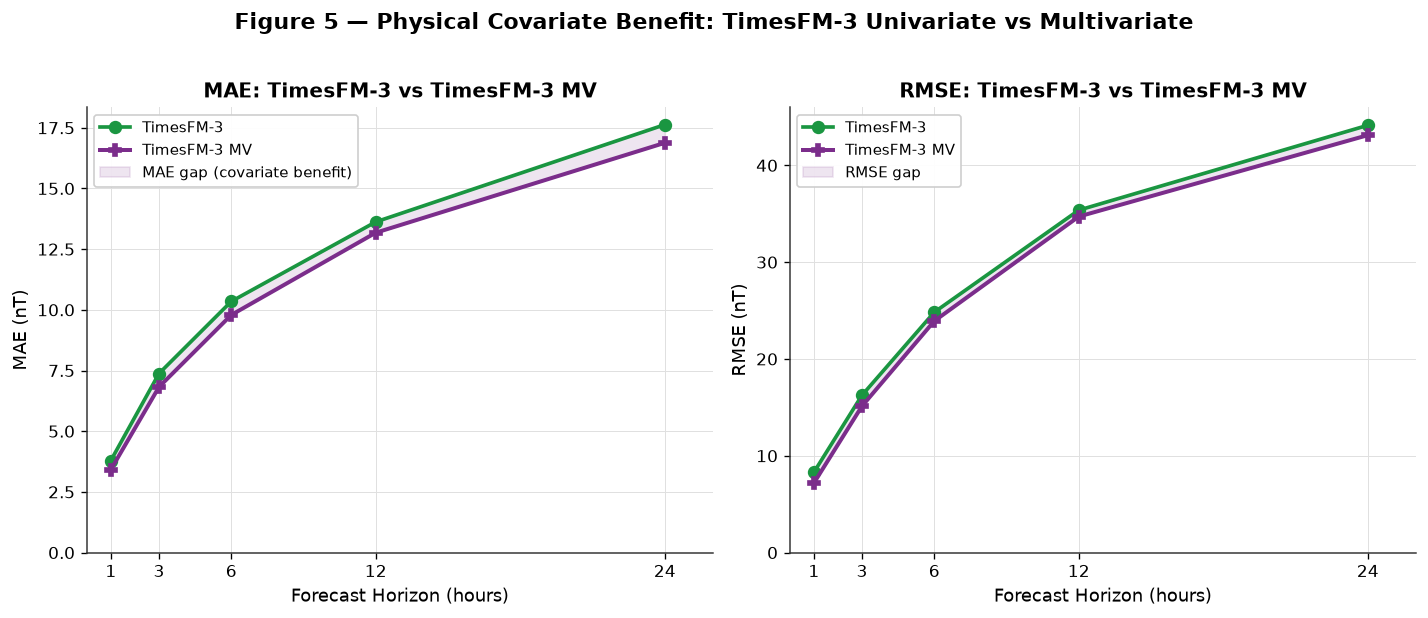

Saved → fig05_covariate_mae_rmse.png


In [12]:
# ── Extract timesfm3 and timesfm3_mv from df_full ─────────────────────────────
_tfm_keys = ["timesfm3", "timesfm3_mv"]
_missing  = [m for m in _tfm_keys if m not in df_full["Model"].unique()]
if _missing:
    print(f"⚠  Missing from tsfm_metrics_full.csv: {_missing}. Skipping Figure 5.")
else:
    sub_univ = df_full[df_full["Model"] == "timesfm3"].sort_values("Horizon")
    sub_mv   = df_full[df_full["Model"] == "timesfm3_mv"].sort_values("Horizon")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

    # ── Left: MAE comparison ───────────────────────────────────────────────────
    ax = axes[0]
    ax.plot(sub_univ["Horizon"], sub_univ["MAE"],
            color=MODEL_COLORS["TimesFM-3"],
            linestyle=MODEL_LINESTYLE["TimesFM-3"],
            marker=MODEL_MARKER["TimesFM-3"],
            label="TimesFM-3", linewidth=2.2)
    ax.plot(sub_mv["Horizon"], sub_mv["MAE"],
            color=MODEL_COLORS["TimesFM-3 MV"],
            linestyle=MODEL_LINESTYLE["TimesFM-3 MV"],
            marker=MODEL_MARKER["TimesFM-3 MV"],
            label="TimesFM-3 MV", linewidth=2.4, zorder=4)

    # Shade the improvement gap
    ax.fill_between(sub_univ["Horizon"].values,
                    sub_univ["MAE"].values,
                    sub_mv["MAE"].values,
                    alpha=0.12, color=MODEL_COLORS["TimesFM-3 MV"],
                    label="MAE gap (covariate benefit)")

    ax.set_xlabel("Forecast Horizon (hours)")
    ax.set_ylabel("MAE (nT)")
    ax.set_title("MAE: TimesFM-3 vs TimesFM-3 MV")
    ax.set_xticks(HORIZONS)
    ax.set_xlim(0, 26)
    ax.set_ylim(bottom=0)
    ax.legend(framealpha=0.95)

    # ── Right: RMSE comparison ─────────────────────────────────────────────────
    ax = axes[1]
    ax.plot(sub_univ["Horizon"], sub_univ["RMSE"],
            color=MODEL_COLORS["TimesFM-3"],
            linestyle=MODEL_LINESTYLE["TimesFM-3"],
            marker=MODEL_MARKER["TimesFM-3"],
            label="TimesFM-3", linewidth=2.2)
    ax.plot(sub_mv["Horizon"], sub_mv["RMSE"],
            color=MODEL_COLORS["TimesFM-3 MV"],
            linestyle=MODEL_LINESTYLE["TimesFM-3 MV"],
            marker=MODEL_MARKER["TimesFM-3 MV"],
            label="TimesFM-3 MV", linewidth=2.4, zorder=4)

    ax.fill_between(sub_univ["Horizon"].values,
                    sub_univ["RMSE"].values,
                    sub_mv["RMSE"].values,
                    alpha=0.12, color=MODEL_COLORS["TimesFM-3 MV"],
                    label="RMSE gap")

    ax.set_xlabel("Forecast Horizon (hours)")
    ax.set_ylabel("RMSE (nT)")
    ax.set_title("RMSE: TimesFM-3 vs TimesFM-3 MV")
    ax.set_xticks(HORIZONS)
    ax.set_xlim(0, 26)
    ax.set_ylim(bottom=0)
    ax.legend(framealpha=0.95)

    fig.suptitle("Figure 5 — Physical Covariate Benefit: TimesFM-3 Univariate vs Multivariate",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "fig05_covariate_mae_rmse.png"))
    plt.show()
    print("Saved → fig05_covariate_mae_rmse.png")


## Figure 6 — Covariate MAE Improvement (%)

The percentage improvement quantifies the benefit of solar-wind covariates relative to the univariate baseline:

$$\text{Covariate Improvement (\%)} = 100 \times \frac{\text{MAE}_{\text{TimesFM-3}} - \text{MAE}_{\text{TimesFM-3 MV}}}{\text{MAE}_{\text{TimesFM-3}}}$$

**Positive values** indicate that the multivariate configuration achieves lower error than the univariate one.

This figure is one of the central application results for SpaceCast: it directly tests whether upstream physical information has predictive value for Dst beyond what recent Dst history already provides.

> **Important scientific caveat:** A lower MAE demonstrates improved predictive performance in this evaluation. It does not establish that the model learned physical solar-wind–magnetosphere coupling.


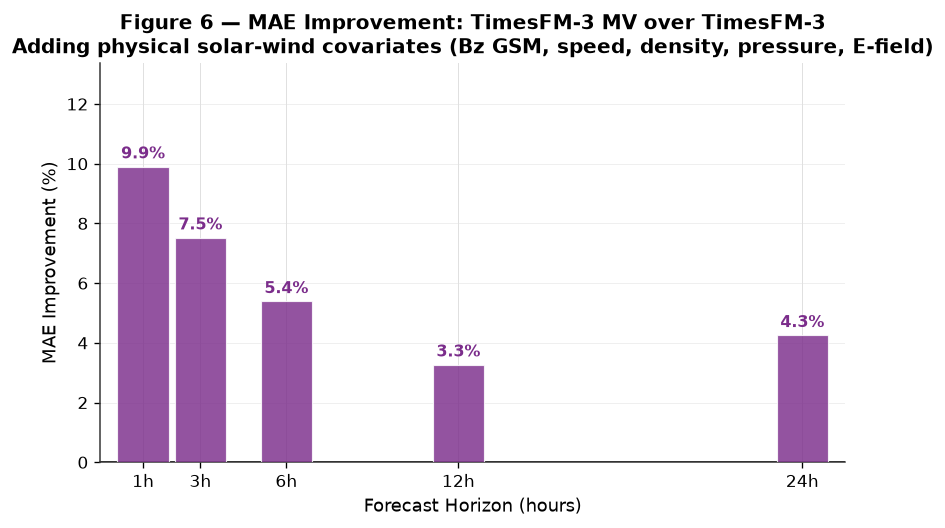

Saved → fig06_covariate_improvement_pct.png

  h= 1h → 9.9% MAE improvement from covariates
  h= 3h → 7.5% MAE improvement from covariates
  h= 6h → 5.4% MAE improvement from covariates
  h=12h → 3.3% MAE improvement from covariates
  h=24h → 4.3% MAE improvement from covariates


In [13]:
_missing = [m for m in ["timesfm3", "timesfm3_mv"] if m not in df_full["Model"].unique()]
if _missing:
    print(f"⚠  Models missing from full metrics: {_missing}. Skipping Figure 6.")
else:
    sub_univ = df_full[df_full["Model"] == "timesfm3"].sort_values("Horizon")
    sub_mv   = df_full[df_full["Model"] == "timesfm3_mv"].sort_values("Horizon")
    horizons_arr = sub_univ["Horizon"].values
    mae_impr_pct = (
        100.0 * (sub_univ["MAE"].values - sub_mv["MAE"].values)
              / sub_univ["MAE"].values
    )

    fig, ax = plt.subplots(figsize=(7, 4.5))

    bars = ax.bar(
        horizons_arr,
        mae_impr_pct,
        width=1.8,
        color=MODEL_COLORS["TimesFM-3 MV"],
        alpha=0.82,
        edgecolor="white",
        linewidth=0.7,
        zorder=3,
    )

    # Annotate bars
    for bar, val in zip(bars, mae_impr_pct):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.15,
            f"{val:.1f}%",
            ha="center", va="bottom", fontsize=9.5, fontweight="bold",
            color=MODEL_COLORS["TimesFM-3 MV"],
        )

    ax.axhline(0, color="#333333", linewidth=1.2, zorder=2)
    ax.set_xlabel("Forecast Horizon (hours)")
    ax.set_ylabel("MAE Improvement (%)")
    ax.set_title(
        "Figure 6 — MAE Improvement: TimesFM-3 MV over TimesFM-3\n"
        "Adding physical solar-wind covariates (Bz GSM, speed, density, pressure, E-field)"
    )
    ax.set_xticks(horizons_arr)
    ax.set_xticklabels([f"{h}h" for h in horizons_arr])
    ax.set_xlim(horizons_arr[0] - 1.5, horizons_arr[-1] + 1.5)
    ax.set_ylim(0, mae_impr_pct.max() * 1.35)
    ax.grid(True, axis="y", alpha=0.5)
    ax.set_axisbelow(True)

    fig.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, "fig06_covariate_improvement_pct.png"))
    plt.show()
    print("Saved → fig06_covariate_improvement_pct.png")
    print()
    for h, v in zip(horizons_arr, mae_impr_pct):
        print(f"  h={h:2d}h → {v:.1f}% MAE improvement from covariates")


## Figure 7 — Storm-Conditioned Forecast Error

**Why global averages are insufficient for space weather assessment:**

The 2024–2025 test period is a mix of quiet intervals (most hours, Dst ≈ 0) and intense storm periods (rare, Dst << −50 nT). During quiet periods, all models — including persistence — perform well because there is little to predict. Global MAE is therefore dominated by easy quiet-time behaviour.

**Operational forecasters care primarily about storm accuracy.**

Storm cases are defined by the **actual future Dst** at horizon $h$:

$$\text{Storm case: } y_{t+h} < -50 \text{ nT} \quad \text{or} \quad y_{t+h} < -100 \text{ nT}$$

This ensures every model is evaluated on **exactly the same set of difficult targets**, independent of the model's own predictions.

> **Note:** Storm-conditioned metrics are available for four univariate models only. TimesFM-3 MV storm metrics were not separately saved by Notebook 04 and are therefore **not shown** here.


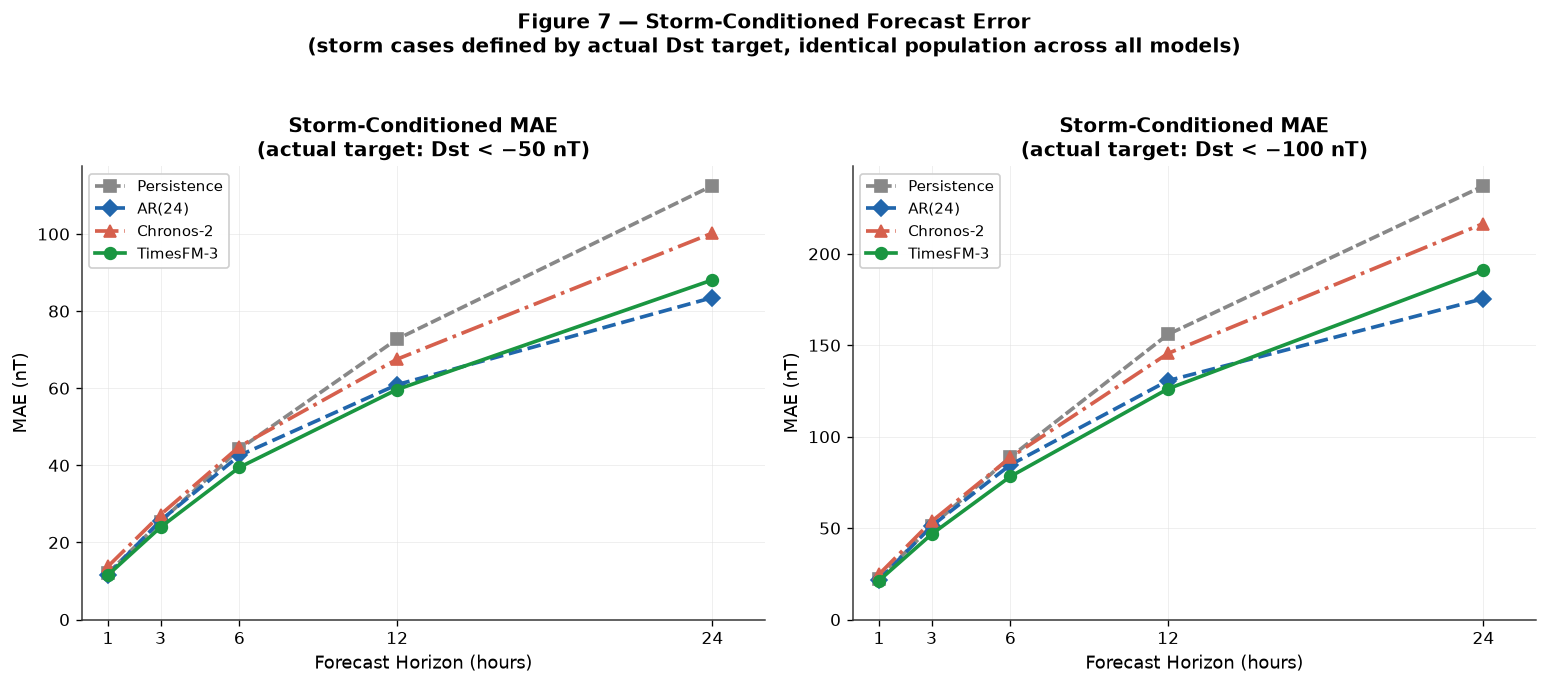

Saved → fig07_storm_conditioned_mae.png


In [14]:
# ── Storm models available (no timesfm3_mv in storm CSV) ──────────────────────
STORM_MODEL_ORDER = ["persistence", "ar24", "chronos2", "timesfm3"]
STORM_MODEL_ORDER = [m for m in STORM_MODEL_ORDER if m in df_storm["Model"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

for ax_idx, (metric_col, thresh_label, thresh_str) in enumerate([
    ("MAE_lt_50",  "Dst < −50 nT",  "50"),
    ("MAE_lt_100", "Dst < −100 nT", "100"),
]):
    ax = axes[ax_idx]
    for m_key in STORM_MODEL_ORDER:
        m_label = LABEL_MAP[m_key]
        sub = df_storm[df_storm["Model"] == m_key].sort_values("Horizon")
        if sub.empty:
            continue
        ax.plot(
            sub["Horizon"], sub[metric_col],
            color=MODEL_COLORS[m_label],
            linestyle=MODEL_LINESTYLE[m_label],
            marker=MODEL_MARKER[m_label],
            label=m_label,
            linewidth=2.2,
        )

    ax.set_xlabel("Forecast Horizon (hours)")
    ax.set_ylabel("MAE (nT)")
    ax.set_title(f"Storm-Conditioned MAE\n(actual target: {thresh_label})")
    ax.set_xticks(HORIZONS)
    ax.set_xlim(0, 26)
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", framealpha=0.95)
    ax.grid(True, alpha=0.5)

fig.suptitle(
    "Figure 7 — Storm-Conditioned Forecast Error\n"
    "(storm cases defined by actual Dst target, identical population across all models)",
    fontsize=12, fontweight="bold", y=1.03,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig07_storm_conditioned_mae.png"))
plt.show()
print("Saved → fig07_storm_conditioned_mae.png")


## Figure 8 — Global vs Storm MAE: The Difficulty Gap

Storm-conditioned errors grow far more rapidly with horizon than global errors.  
At 24 h, the gap between global MAE and storm-conditioned MAE (Dst < −50 nT) is roughly **4–5× the global MAE** for all models.

This figure directly contrasts global MAE against storm-conditioned MAE for the two strongest models — **TimesFM-3** and **AR(24)** — to show where operational forecasting remains the hardest challenge.

Understanding this gap is essential: a model that looks competitive globally may still fail dramatically during the events that matter most.


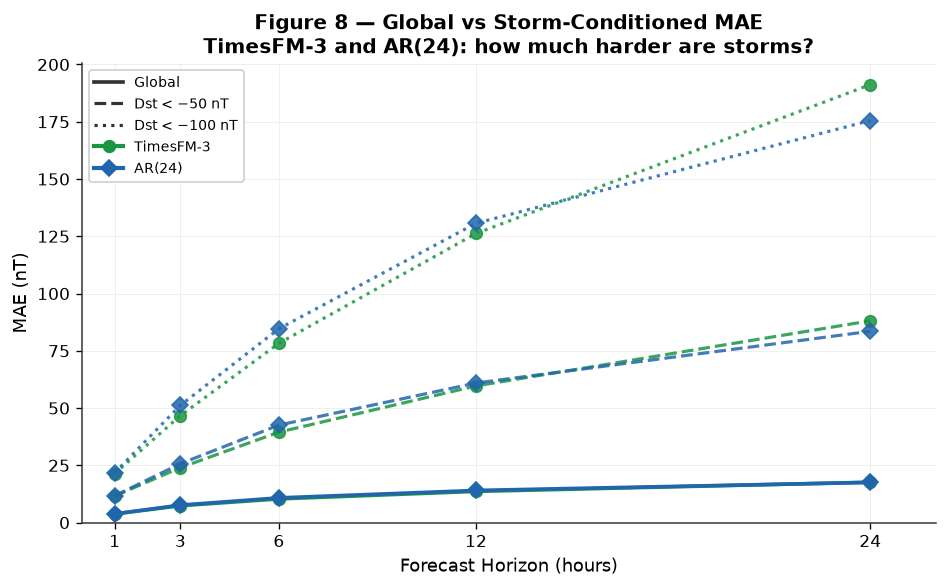

Saved → fig08_global_vs_storm_mae.png


In [16]:
# ── Global vs storm MAE for TimesFM-3 and AR(24) ──────────────────────────────
_focus_models = [m for m in ["timesfm3", "ar24"] if m in df_storm["Model"].unique()]

fig, ax = plt.subplots(figsize=(8, 5))

line_specs = {
    "global":    {"linestyle": "-",    "alpha": 1.0,  "linewidth": 2.2},
    "storm_50":  {"linestyle": "--",   "alpha": 0.85, "linewidth": 1.9},
    "storm_100": {"linestyle": ":",    "alpha": 0.85, "linewidth": 1.9},
}

handles = []
for m_key in _focus_models:
    m_label  = LABEL_MAP[m_key]
    color    = MODEL_COLORS[m_label]
    marker   = MODEL_MARKER[m_label]

    # Global MAE
    sub_g = df_full[df_full["Model"] == m_key].sort_values("Horizon")
    ln_g, = ax.plot(sub_g["Horizon"], sub_g["MAE"],
                    color=color, marker=marker,
                    **line_specs["global"],
                    label=f"{m_label} — Global")

    # Storm MAE < -50
    sub_s50 = df_storm[df_storm["Model"] == m_key].sort_values("Horizon")
    ln_50, = ax.plot(sub_s50["Horizon"], sub_s50["MAE_lt_50"],
                     color=color, marker=marker,
                     **line_specs["storm_50"],
                     label=f"{m_label} — Dst<−50 nT")

    # Storm MAE < -100
    ln_100, = ax.plot(sub_s50["Horizon"], sub_s50["MAE_lt_100"],
                      color=color, marker=marker,
                      **line_specs["storm_100"],
                      label=f"{m_label} — Dst<−100 nT")

# Legend: line style explains condition; color explains model
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="#333333", lw=2.2, linestyle="-",  label="Global"),
    Line2D([0], [0], color="#333333", lw=1.9, linestyle="--", label="Dst < −50 nT"),
    Line2D([0], [0], color="#333333", lw=1.9, linestyle=":",  label="Dst < −100 nT"),
    Line2D([0], [0], color=MODEL_COLORS["TimesFM-3"], lw=2.5,
           marker=MODEL_MARKER["TimesFM-3"], label="TimesFM-3"),
    Line2D([0], [0], color=MODEL_COLORS["AR(24)"],   lw=2.5,
           marker=MODEL_MARKER["AR(24)"],    label="AR(24)"),

]
ax.legend(handles=legend_elements, loc="upper left", framealpha=0.95, fontsize=8.5)

ax.set_xlabel("Forecast Horizon (hours)")
ax.set_ylabel("MAE (nT)")
ax.set_title(
    "Figure 8 — Global vs Storm-Conditioned MAE\n"
    "TimesFM-3 and AR(24): how much harder are storms?"
)
ax.set_xticks(HORIZONS)
ax.set_xlim(0, 26)
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.5)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig08_global_vs_storm_mae.png"))
plt.show()
print("Saved → fig08_global_vs_storm_mae.png")


## May 2024 G5 Geomagnetic Storm — Physical Case Study

The **May 2024 geomagnetic storm** (approximately May 9–12, 2024) is the most intense event in the SpaceCast test period and one of the strongest storms in two decades. It reached **G5 severity** (the highest NOAA Geomagnetic Storm scale level), driven by a sequence of coronal mass ejections (CMEs) from an exceptionally active solar region during the ascending phase of Solar Cycle 25.

**Key facts confirmed from the OMNI2 data:**
- Dst minimum: **−406 nT** at 2024-05-11 02:00 UTC
- 45% of the May 8–14 window had Dst < −50 nT
- 26% had Dst < −100 nT  
- Solar-wind speed reached **1,006 km/s**
- Bz GSM dropped to **−35 nT** (strongly southward — the primary geoeffective driver)

Notebook 04 sampled forecast origins **every 1 hour** during May 8–15, providing high temporal resolution for this event in the storm-conditioned evaluation.

The following figures show the raw solar-wind and geomagnetic observations, followed by the model performance comparison during this window using the available aggregate metrics.


In [17]:
# ── Load OMNI2 and prepare May 2024 window ─────────────────────────────────────
_omni_path = os.path.join(DATA_DIR, "omni2_2016_2025_clean.csv")
if not os.path.isfile(_omni_path):
    raise FileNotFoundError(
        f"OMNI2 clean data not found at: {_omni_path}\n"
        "Expected at data/raw/omni2_2016_2025_clean.csv"
    )

df_omni = pd.read_csv(
    _omni_path,
    parse_dates=["datetime"],
    index_col="datetime",
    low_memory=False,
)

# ── May 2024 window ────────────────────────────────────────────────────────────
MAY_START = "2024-05-08 00:00"
MAY_END   = "2024-05-14 23:00"
df_may = df_omni.loc[MAY_START:MAY_END,
                     ["Dst_nT", "Bz_gsm_nT", "speed_km_s",
                      "density_cm3", "flow_pressure_nPa", "AE_nT"]].copy()

print(f"May 2024 window: {df_may.index.min()}  →  {df_may.index.max()}")
print(f"Hours          : {len(df_may)}")
print(f"Dst minimum    : {df_may['Dst_nT'].min():.0f} nT  at  {df_may['Dst_nT'].idxmin()}")
print(f"Bz GSM minimum : {df_may['Bz_gsm_nT'].min():.1f} nT")
print(f"Speed maximum  : {df_may['speed_km_s'].max():.0f} km/s")
print(f"Missing values : {df_may.isna().sum().to_dict()}")


May 2024 window: 2024-05-08 00:00:00  →  2024-05-14 23:00:00
Hours          : 168
Dst minimum    : -406 nT  at  2024-05-11 02:00:00
Bz GSM minimum : -35.3 nT
Speed maximum  : 1006 km/s
Missing values : {'Dst_nT': 0, 'Bz_gsm_nT': 0, 'speed_km_s': 1, 'density_cm3': 1, 'flow_pressure_nPa': 1, 'AE_nT': 0}


## Figure 9 — May 2024 Solar-Wind Drivers and Geomagnetic Response

This multi-panel figure connects **upstream solar-wind conditions** to the **geomagnetic Dst response** during the May 2024 G5 storm.

Four panels (top to bottom):

1. **Solar-wind speed (km/s):** CME arrival is reflected in the speed jump.
2. **Solar-wind density (cm⁻³):** High density amplifies the dynamic pressure and ring-current injection.
3. **Bz GSM (nT):** The north–south IMF component is the primary driver of geomagnetic activity. Sustained southward (negative) Bz allows efficient energy transfer from the solar wind to the magnetosphere.
4. **Dst (nT):** The geomagnetic response — a deeply negative Dst indicates severe ring-current intensification.

> **Physical note:** No single upstream variable deterministically determines Dst — the relationship involves complex, time-lagged, nonlinear coupling through the magnetospheric system. This figure visualises correlation in time, not causation.


C:\Users\Shaleen Garg\AppData\Local\Temp\ipykernel_19048\4230839482.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


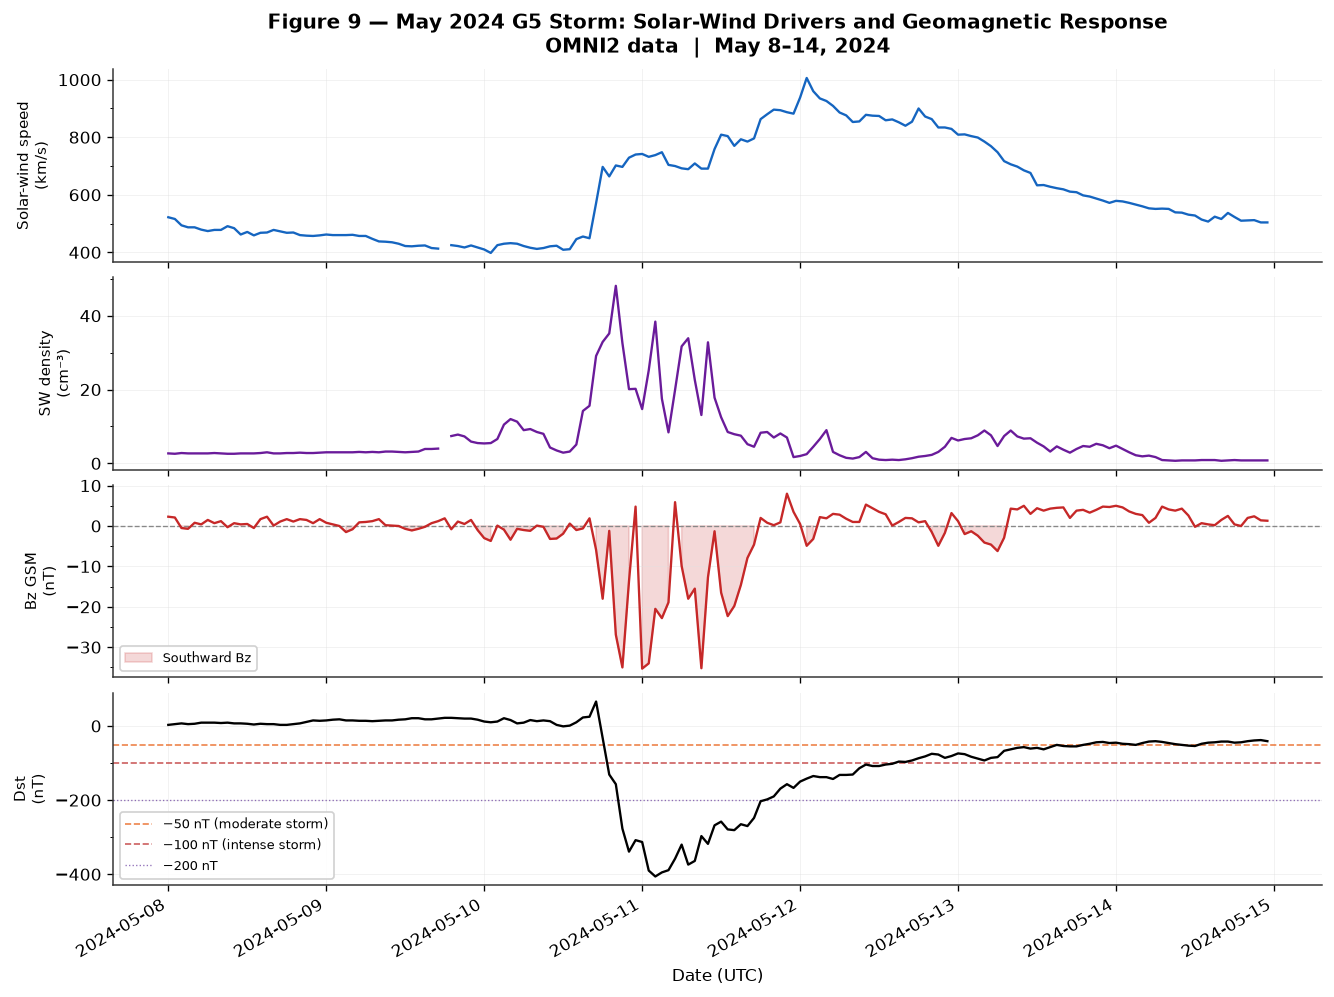

Saved → fig09_may2024_solar_wind_dst.png


In [18]:
fig = plt.figure(figsize=(13, 10))
gs  = GridSpec(4, 1, figure=fig, hspace=0.08)

time_arr = df_may.index

panel_specs = [
    ("speed_km_s",      "Solar-wind speed\n(km/s)",    "#1565c0", None),
    ("density_cm3",     "SW density\n(cm⁻³)",          "#6a1b9a", None),
    ("Bz_gsm_nT",       "Bz GSM\n(nT)",                "#c62828", 0.0),
    ("Dst_nT",          "Dst\n(nT)",                    "#000000", None),
]

axs = []
for i, (col, ylabel, color, hline) in enumerate(panel_specs):
    ax = fig.add_subplot(gs[i], sharex=axs[0] if axs else None)
    axs.append(ax)

    ax.plot(time_arr, df_may[col], color=color, linewidth=1.4, zorder=3)

    if hline is not None:
        ax.axhline(hline, color="#888888", linewidth=0.8, linestyle="--", zorder=2)

    # Dst thresholds
    if col == "Dst_nT":
        ax.axhline(-50,  color="#e65100", linewidth=1.0, linestyle="--",
                   alpha=0.7, label="−50 nT (moderate storm)")
        ax.axhline(-100, color="#b71c1c", linewidth=1.0, linestyle="--",
                   alpha=0.7, label="−100 nT (intense storm)")
        ax.axhline(-200, color="#4a148c", linewidth=0.8, linestyle=":",
                   alpha=0.6, label="−200 nT")
        ax.legend(loc="lower left", fontsize=8, framealpha=0.9)

    # Bz southward shading
    if col == "Bz_gsm_nT":
        ax.fill_between(time_arr, df_may[col], 0,
                        where=(df_may[col] < 0),
                        color="#c62828", alpha=0.18, label="Southward Bz")
        ax.legend(loc="lower left", fontsize=8, framealpha=0.9)

    ax.set_ylabel(ylabel, fontsize=9, labelpad=4)
    ax.grid(True, alpha=0.4)
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))

    # Only show x-tick labels on the bottom panel
    if i < len(panel_specs) - 1:
        plt.setp(ax.get_xticklabels(), visible=False)
    else:
        ax.set_xlabel("Date (UTC)", fontsize=10)
        fig.autofmt_xdate(rotation=30, ha="right")

axs[0].set_title(
    "Figure 9 — May 2024 G5 Storm: Solar-Wind Drivers and Geomagnetic Response\n"
    "OMNI2 data  |  May 8–14, 2024",
    fontsize=12, fontweight="bold", pad=10,
)

fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig09_may2024_solar_wind_dst.png"))
plt.show()
print("Saved → fig09_may2024_solar_wind_dst.png")


## Figure 10 — Model Performance During the May 2024 Event

**An important constraint must be stated clearly:**

Notebook 04 did **not serialise** raw per-origin forecast arrays to disk.  
The in-memory `univariate_results` list (containing per-origin predictions) was never saved as a file.

This means:
- We cannot reconstruct continuous model forecast trajectories over the May 2024 storm window.
- We **must not invent** or reconstruct fake forecasts from aggregate statistics.

**What we *can* do:**  
The storm-conditioned metrics in `tsfm_metrics_dst_lt_50.csv` reflect all storm-time origins across the full 2024–2025 test period. The May 2024 G5 event is the dominant contributor to the `Dst < −100 nT` population (Dst reached −406 nT). These aggregate metrics are the strongest valid proxy for model behaviour during this event.

Figure 10 therefore presents the **storm-conditioned MAE by horizon** as a focused, event-informed model comparison — clearly labelled as aggregate metrics, not reconstructed event trajectories.

> To enable per-event trajectory plots in a future version, Notebook 04 should be extended to save the `univariate_results` arrays (e.g., as `.npz` or `.parquet`) before the session ends.


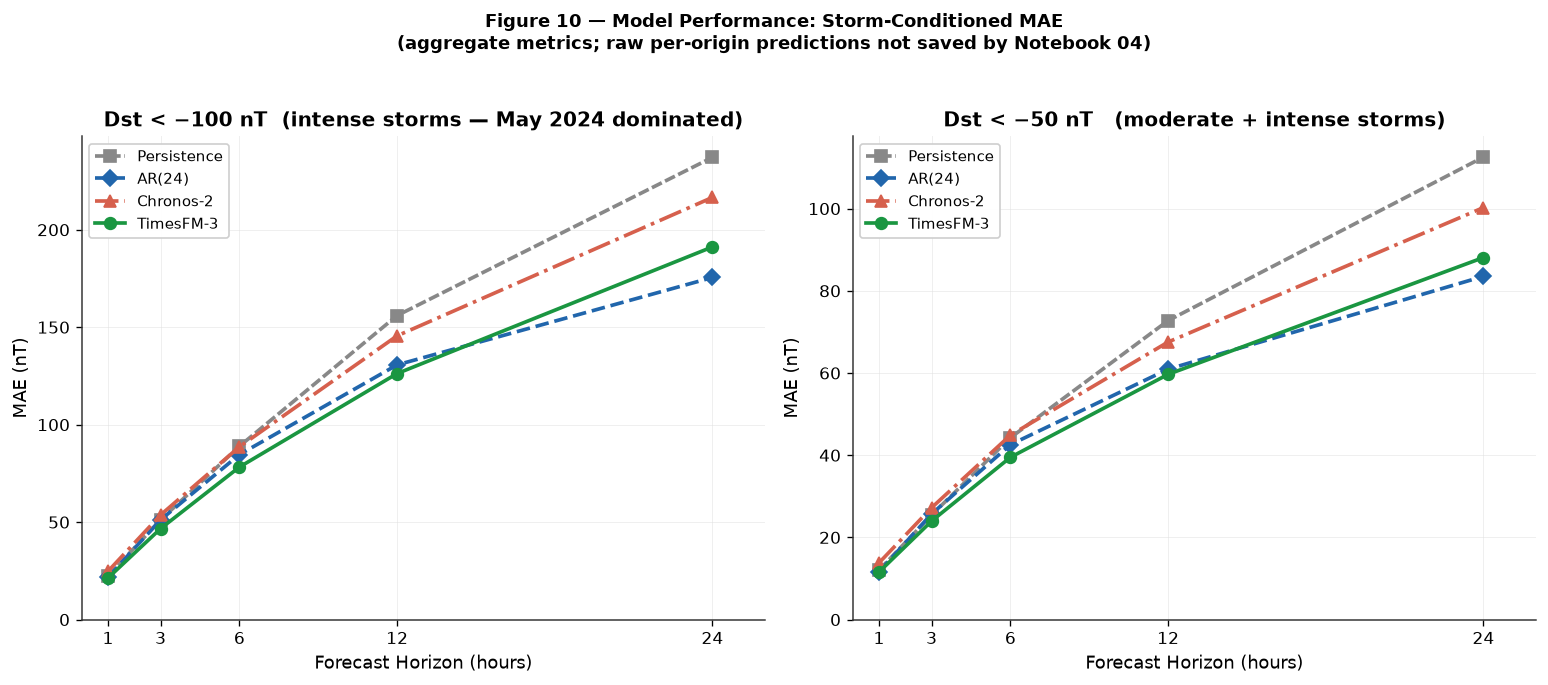

Saved → fig10_may2024_storm_performance.png

Storm population sizes (number of forecast origins) by horizon:
         Count_lt_50  Count_lt_100
Horizon                           
1                164            55
3                159            57
6                162            60
12               159            53
24               159            53

Note: counts are identical across models because storm conditioning uses actual Dst.


In [19]:
# ── Storm-conditioned model comparison: closest valid proxy for May 2024 ───────
# The Dst < -100 nT population is dominated by the May 2024 G5 event.

_focus_storm_models = [m for m in STORM_MODEL_ORDER if m in df_storm["Model"].unique()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=False)

for ax_idx, (metric_col, rmse_col, thresh_label) in enumerate([
    ("MAE_lt_100", "RMSE_lt_100", "Dst < −100 nT  (intense storms — May 2024 dominated)"),
    ("MAE_lt_50",  "RMSE_lt_50",  "Dst < −50 nT   (moderate + intense storms)"),
]):
    ax = axes[ax_idx]
    for m_key in _focus_storm_models:
        m_label = LABEL_MAP[m_key]
        sub = df_storm[df_storm["Model"] == m_key].sort_values("Horizon")
        ax.plot(
            sub["Horizon"], sub[metric_col],
            color=MODEL_COLORS[m_label],
            linestyle=MODEL_LINESTYLE[m_label],
            marker=MODEL_MARKER[m_label],
            label=m_label,
            linewidth=2.2,
        )

    ax.set_xlabel("Forecast Horizon (hours)")
    ax.set_ylabel("MAE (nT)")
    ax.set_title(f"{thresh_label}")
    ax.set_xticks(HORIZONS)
    ax.set_xlim(0, 26)
    ax.set_ylim(bottom=0)
    ax.legend(loc="upper left", framealpha=0.95)
    ax.grid(True, alpha=0.5)

fig.suptitle(
    "Figure 10 — Model Performance: Storm-Conditioned MAE\n"
    "(aggregate metrics; raw per-origin predictions not saved by Notebook 04)",
    fontsize=11, fontweight="bold", y=1.03,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig10_may2024_storm_performance.png"))
plt.show()
print("Saved → fig10_may2024_storm_performance.png")

# ── Annotate: actual storm sample sizes ───────────────────────────────────────
print("\nStorm population sizes (number of forecast origins) by horizon:")
counts = (
    df_storm[df_storm["Model"] == "persistence"]
    [["Horizon", "Count_lt_50", "Count_lt_100"]]
    .sort_values("Horizon")
    .set_index("Horizon")
)
print(counts.to_string())
print("\nNote: counts are identical across models because storm conditioning uses actual Dst.")


## Final Model Scorecard

No single metric tells the full forecasting story:

- **MAE** summarises typical absolute error
- **RMSE** reveals sensitivity to large storm-time misses
- **Pearson correlation** reflects temporal co-movement
- **Storm MAE (Dst < −50 nT)** captures operational extreme-event performance

The final scorecard visualises all three primary metrics across all five horizons for every model in one compact, readable figure.

**Reading the heatmap:**  
- MAE and RMSE cells: **darker = higher error = worse**. Values in nT.  
- Correlation cells: **darker = lower correlation = worse**. Unitless.  
- Each sub-block shows one metric; models are rows, horizons are columns.
- Color scales are normalised **within each metric independently**, so colours are comparable only within a metric panel, not across panels.


findfont: Failed to find font weight semibold, now using 700.


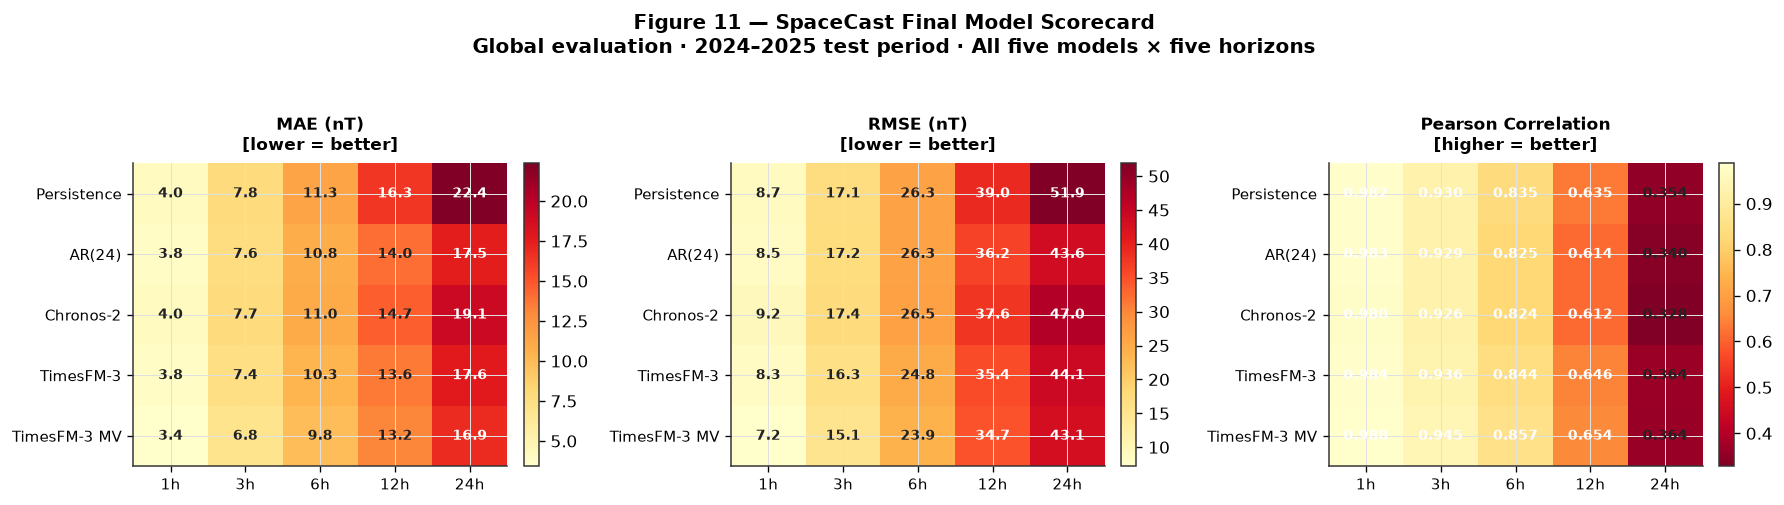

Saved → fig11_final_scorecard_heatmap.png


In [20]:
# ── Build scorecard data structures ────────────────────────────────────────────
_models_in_full  = [m for m in MODEL_ORDER if m in df_full["Model"].unique()]
_display_labels  = [LABEL_MAP[m] for m in _models_in_full]

def _make_pivot(metric):
    piv = (
        df_full[df_full["Model"].isin(_models_in_full)]
        .pivot(index="Model", columns="Horizon", values=metric)
        .reindex(_models_in_full)
    )
    piv.index = _display_labels
    return piv

piv_mae  = _make_pivot("MAE")
piv_rmse = _make_pivot("RMSE")
piv_corr = _make_pivot("Correlation")

# ── Figure: 3-panel heatmap scorecard ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))

def draw_heatmap(ax, data, title, cmap, fmt, vmin=None, vmax=None, annot_color_thresh=0.6):
    """Draw a clean heatmap with annotated values."""
    if vmin is None:
        vmin = data.values.min()
    if vmax is None:
        vmax = data.values.max()

    im = ax.imshow(data.values, aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)

    # Annotate each cell
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            val = data.values[r, c]
            norm_val = (val - vmin) / (vmax - vmin + 1e-10)
            text_color = "white" if norm_val > annot_color_thresh else "#222222"
            ax.text(c, r, fmt.format(val),
                    ha="center", va="center", fontsize=8.5,
                    color=text_color, fontweight="semibold")

    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels([f"{h}h" for h in HORIZONS], fontsize=9)
    ax.set_yticks(range(len(_display_labels)))
    ax.set_yticklabels(_display_labels, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold", pad=8)

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im

draw_heatmap(axes[0], piv_mae,  "MAE (nT)\n[lower = better]",
             "YlOrRd", "{:.1f}")
draw_heatmap(axes[1], piv_rmse, "RMSE (nT)\n[lower = better]",
             "YlOrRd", "{:.1f}")
draw_heatmap(axes[2], piv_corr, "Pearson Correlation\n[higher = better]",
             "YlOrRd_r", "{:.3f}", annot_color_thresh=0.4)

fig.suptitle(
    "Figure 11 — SpaceCast Final Model Scorecard\n"
    "Global evaluation · 2024–2025 test period · All five models × five horizons",
    fontsize=12, fontweight="bold", y=1.04,
)
fig.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "fig11_final_scorecard_heatmap.png"))
plt.show()
print("Saved → fig11_final_scorecard_heatmap.png")


## Final Findings

The following conclusions are drawn **strictly from the actual evaluation results** in the saved metric files. They describe observed performance on the 2024–2025 held-out test period. They are not claims of statistical significance (forecast windows overlap and are not independent samples) and are not claims of physical causality.

---

### 1. Error grows consistently with forecast horizon
Across all five models, MAE and RMSE increase monotonically from 1 h to 24 h. The sharpest growth occurs between 6 h and 24 h, reflecting the rapid decorrelation of the geomagnetic state over multi-hour timescales.

### 2. TimesFM-3 MV achieves the lowest MAE at every evaluated horizon
From 3.42 nT at 1 h to 16.88 nT at 24 h, the multivariate TimesFM-3 configuration achieves the lowest point-forecast error in this evaluation across all five lead times.

### 3. Adding solar-wind covariates improves TimesFM-3
The MAE reduction from univariate to multivariate TimesFM-3 ranges from **~9.9% at 1 h to ~3.3% at 12 h**, recovering to ~4.3% at 24 h. This improvement is consistent across horizons and confirms that recently observed physical solar-wind information carries predictive value for Dst beyond what Dst history alone provides. This is an evaluation result, not a claim of physical understanding.

### 4. Short-horizon persistence is a strong and meaningful benchmark
At 1 h, Dst autocorrelation is near 0.98, making persistence the hardest baseline to beat. A model that fails to beat persistence at 1 h adds no operational value. TimesFM-3 MV improves over persistence by **~15%** at 1 h; all other models show smaller improvements.

### 5. Storm-conditioned errors are substantially larger than global errors
During Dst < −100 nT events, 24-hour MAE reaches 175–237 nT across models — roughly **10× the global MAE at the same horizon**. Extreme-event forecasting from past Dst history alone remains an unsolved problem at long lead times.

### 6. Chronos-2 does not consistently beat AR(24) in this evaluation
Chronos-2 achieves lower MAE than persistence at longer horizons, but does not match AR(24) or TimesFM-3 at any evaluated horizon. Its RMSE is notably higher than the other models at 24 h, indicating a heavier tail of large errors.

### 7. No claim of statistical significance
Forecast origins overlap substantially (sampled every 12 h globally, every 1 h during the storm window). The resulting evaluation windows are not independent observations. The results quantify descriptive forecasting performance on this test period. Formal significance testing would require a block-bootstrap or equivalent approach accounting for serial dependence.

### 8. No claim of physical causality
Lower MAE for the multivariate model indicates improved predictive performance from adding solar-wind context. It does not establish that TimesFM-3 learned physical solar-wind–magnetosphere coupling mechanisms.


## SpaceCast — Final Takeaway

SpaceCast is an end-to-end application demonstration of geomagnetic Dst forecasting using a structured progression of methods:

